### Крок 3 — вибір вікна усереднення

Питання: з якої позиції бурста почати рахувати soil_raw, і на якій зупинитись, щоб надіслати одне усереднене значення — компроміс між точністю і часом роботи Vext (= споживанням батареї).

Що вже встановлено раніше:
 - позиція 0 (0.45с від Vext ON) систематично занижена на ~−22 одиниці, стабільно у 442 з 442 бурстів (01_burst_shape (./01_burst_shape.ipynb))
 - позиції ≥2 (від ~6.8с) — усталена зона, шум усередині якої ~1.74 одиниці (01_burst_shape (./01_burst_shape.ipynb))
 - реальна зміна вологості за 15 хв (~1.38) менша за цей шум — тобто всередині одного бурста (19.5с) нічому "розмазуватись", усереднення прибирає тільки шум, не втрачає сигнал (02_trend_dynamics (./02_trend_dynamics.ipynb))

Що рахуємо тут: для кожного можливого вікна [start..end] (наприклад, [1..6], [2..4], [2..6]) — яка похибка усередненого значення відносно "істини" (усталеного плато бурста), і скільки секунд Vext і LoRa-передач це вікно коштує. Мета — знайти найкоротше вікно, яке ще не програє по точності.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

path = Path("data/measurement.csv")
df = pd.read_csv(path, parse_dates=["timestamp"])
low = df[(df["node_id"] == "stage3-lowpower") & (df["timestamp"] >= "2026-08-25")]
low = low.sort_values(by="timestamp")

gaps = low["timestamp"].diff().dt.total_seconds()
new_burst = gaps > 45

low["burst_id"] = new_burst.cumsum()
low["pos_in_burst"] = low.groupby("burst_id").cumcount()

burst_sizes = low.groupby("burst_id").size()
full_burst_ids = burst_sizes[burst_sizes == 7].index
low = low[low["burst_id"].isin(full_burst_ids)]

print(low.shape)

(3094, 13)


In [2]:
wide = low.pivot(index="burst_id", columns="pos_in_burst", values="soil_raw")
print(wide.shape)
print(wide.head())

(442, 7)
pos_in_burst       0       1       2       3       4       5       6
burst_id                                                            
131           1272.0  1295.0  1293.0  1293.0  1295.0  1297.0  1294.0
132           1273.0  1293.0  1294.0  1293.0  1295.0  1294.0  1299.0
133           1273.0  1298.0  1299.0  1295.0  1298.0  1294.0  1299.0
134           1273.0  1294.0  1295.0  1297.0  1299.0  1295.0  1294.0
135           1271.0  1293.0  1297.0  1295.0  1295.0  1295.0  1293.0


In [3]:
truth = wide[[5, 6]].mean(axis=1)
print(truth.head())

burst_id
131    1295.5
132    1296.5
133    1296.5
134    1294.5
135    1294.0
dtype: float64


In [4]:
TICK = 3.17
T0 = 0.45

windows = [(1,1), (1,2), (1,3), (1,4), (2,2), (2,3), (2,4), (3,3), (3,4), (4,4)]

results = []
for start, end in windows:
    cols = list(range(start, end + 1))
    window_mean = wide[cols].mean(axis=1)
    error = (window_mean - truth).abs()
    elapsed = T0 + end * TICK
    results.append({
        "window": f"{start}..{end}",
        "n_samples": len(cols),
        "elapsed_s": round(elapsed, 2),
        "median_err": round(error.median(), 3),
        "p90_err": round(error.quantile(0.9), 3),
    })

result_table = pd.DataFrame(results)
print(result_table)

  window  n_samples  elapsed_s  median_err  p90_err
0   1..1          1       3.62        1.50    4.500
1   1..2          2       6.79        1.50    3.500
2   1..3          3       9.96        1.25    3.167
3   1..4          4      13.13        1.00    3.000
4   2..2          1       6.79        1.50    4.000
5   2..3          2       9.96        1.00    3.500
6   2..4          3      13.13        1.00    2.833
7   3..3          1       9.96        1.25    3.500
8   3..4          2      13.13        1.00    3.000
9   4..4          1      13.13        1.00    3.000


end      1    2      3      4
start                        
1      4.5  3.5  3.167  3.000
2      NaN  4.0  3.500  2.833
3      NaN  NaN  3.500  3.000
4      NaN  NaN    NaN  3.000


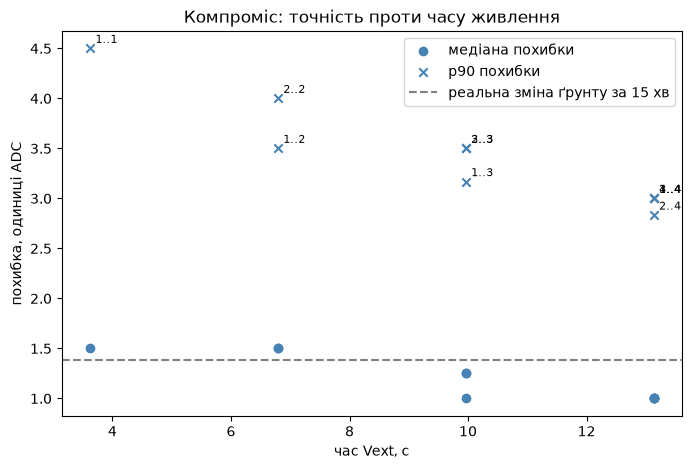

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(result_table["elapsed_s"], result_table["median_err"], label="медіана похибки", color="steelblue")
plt.scatter(result_table["elapsed_s"], result_table["p90_err"], label="p90 похибки", color="steelblue", marker="x")

for _, row in result_table.iterrows():
    plt.annotate(row["window"], (row["elapsed_s"], row["p90_err"]),
                 fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.axhline(1.38, color="gray", linestyle="--", label="реальна зміна ґрунту за 15 хв")

plt.xlabel("час Vext, с")
plt.ylabel("похибка, одиниці ADC")
plt.title("Компроміс: точність проти часу живлення")
plt.legend()

result_table[["start", "end"]] = result_table["window"].str.split("..", expand=True, regex=False).astype(int)
heat = result_table.pivot(index="start", columns="end", values="p90_err")
print(heat)

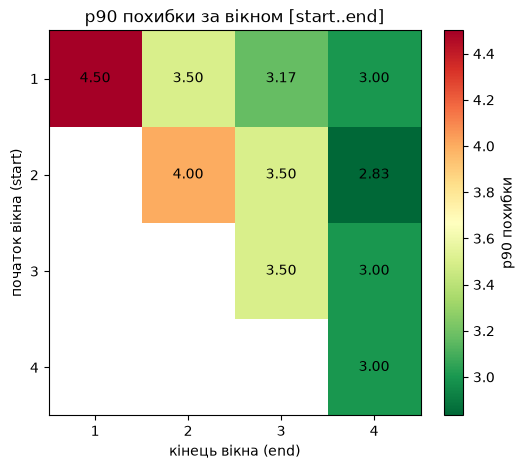

In [6]:
plt.figure(figsize=(6, 5))
plt.imshow(heat, cmap="RdYlGn_r", aspect="auto")
plt.colorbar(label="p90 похибки")
plt.xticks(range(len(heat.columns)), heat.columns)
plt.yticks(range(len(heat.index)), heat.index)
plt.xlabel("кінець вікна (end)")
plt.ylabel("початок вікна (start)")
plt.title("p90 похибки за вікном [start..end]")

for i, start in enumerate(heat.index):
    for j, end in enumerate(heat.columns):
        val = heat.loc[start, end]
        if pd.notna(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", color="black")



### Фінальний висновок: вибір вікна

Два найкращі кандидати за співвідношенням точність/вартість:
  - [1..3] — 3 відліки, 9.96с Vext, p90 = 3.17
  - [2..4] — 3 відліки, 13.13с Vext, p90 = 2.83

Обидва мають по 3 відліки і виглядають дуже добре. Різниця в точності (3.17 проти 2.83) невелика і, ймовірно, лежить у межах шуму самої оцінки p90 (порахованого лише на 442 бурстах) — тому вибір між ними вільний: [2..4] трохи точніше, [1..3] — дешевше (на ~3.2с менше часу живлення).

Окремо варто відзначити [3..4] — 2 відліки, 13.13с, p90 = 3.00 — теж хороша точність. Але це лише 2 відліки проти 3 у попередніх варіантів. З кроку 1.3 відомо: ~13.1% бурстів low неповні (втрачається пакет чи відлік). При 3 відліках втрата одного все одно лишає 2 для усереднення; при 2 відліках втрата одного лишає лише 1 — без усереднення, без страховки. Тому за критерієм надійності перевага — вікнам саме з 3 відліків ([1..3] чи [2..4]), а не з 2, попри схожу точність.

Що не перевірено: реальна вартість по батареї (vbat — напруга, не струм/енергія; потрібен окремий струмовий сенсор для чесного порівняння). Фінальний вибір між [1..3] і [2..4] — за польовим тестом.

Text(0.5, 1.0, 'Було / стало: скорочення циклу вимірювання')

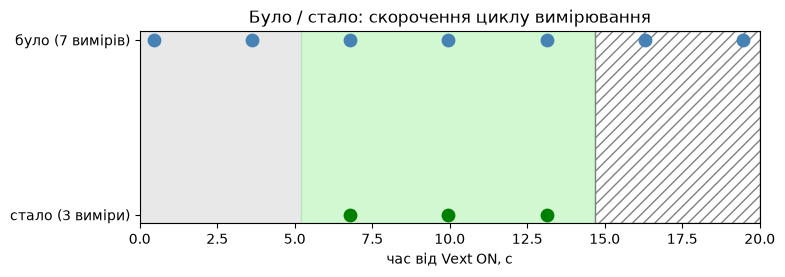

In [7]:
plt.figure(figsize=(8, 2.5))

before_t = [0.45, 3.62, 6.79, 9.96, 13.13, 16.30, 19.47]
after_t = [6.79, 9.96, 13.13]

plt.axvspan(0, 5.2, color="lightgray", alpha=0.5)                       # занадто рано
plt.axvspan(5.2, 14.7, color="lightgreen", alpha=0.4)                   # усталена зона
plt.axvspan(14.7, 20, facecolor="none", edgecolor="gray", hatch="///")  # зайве

plt.scatter(before_t, [1]*len(before_t), color="steelblue", s=80, zorder=3)
plt.scatter(after_t, [0]*len(after_t), color="green", s=80, zorder=3)

plt.yticks([0, 1], ["стало (3 виміри)", "було (7 вимірів)"])
plt.xlabel("час від Vext ON, с")
plt.xlim(0, 20)
plt.title("Було / стало: скорочення циклу вимірювання")

p90 ≈ 2.8-3.2, 3 виміри — страховка від втрати пакета, ~35% менше часу живлення. Реальна економія по батареї не перевірена (нема струмового сенсора)